## Post Deseq2 analyses an

In [1]:
import pandas as pd 
import numpy as np 
import scipy
from matplotlib.colors import ListedColormap
import scikit_posthocs
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator
sns.set(font_scale=1.4)
matplotlib.rcParams['pdf.fonttype'] = 42

In [7]:
# first generate files for up and down genes from each comparison

s34fcsc_comparison = pd.read_csv('/Users/selammehreteab/Desktop/deseq2_updated/u2af1_illumina_s34f_csc_vs_u2af1_illumina_wt_dmso', sep=',')
s34fdmso_comparison = pd.read_csv('/Users/selammehreteab/Desktop/deseq2_updated/u2af1_illumina_s34f_dmso_vs_u2af1_illumina_wt_dmso', sep=',')
wtcsc_comparison = pd.read_csv('/Users/selammehreteab/Desktop/deseq2_updated/u2af1_illumina_wt_csc_vs_u2af1_illumina_wt_dmso', sep=',')


In [8]:
wtcsc_log2fc_one = wtcsc_comparison.loc[wtcsc_comparison['log2FoldChange'].abs() >= 1] 
s34fcsc_log2fc_one = s34fcsc_comparison.loc[s34fcsc_comparison['log2FoldChange'].abs() >= 1] 
s34fdmso_log2fc_one = s34fdmso_comparison.loc[s34fdmso_comparison['log2FoldChange'].abs() >= 1] 

In [9]:
wtcsc =wtcsc_log2fc_one.loc[wtcsc_log2fc_one['padj'] <= 0.05] 
s34fdmso =s34fdmso_log2fc_one.loc[s34fdmso_log2fc_one['padj'] <= 0.05] 
s34fcsc =s34fcsc_log2fc_one.loc[s34fcsc_log2fc_one['padj'] <= 0.05] 

In [10]:
dfs = { "WT CSC":wtcsc, "S34F DMSO":s34fdmso, "S34F CSC":s34fcsc}

summary = []

for name, df in dfs.items():
    summary.append({
        "sample": name,
        "Up": (df['log2FoldChange'] > 0).sum(),
        "Down": (df['log2FoldChange'] < 0).sum()
    })

summary_df = pd.DataFrame(summary).set_index("sample")
summary_df

,Up,Down
sample,,
WT CSC,174,129
S34F DMSO,1443,1565
S34F CSC,739,733


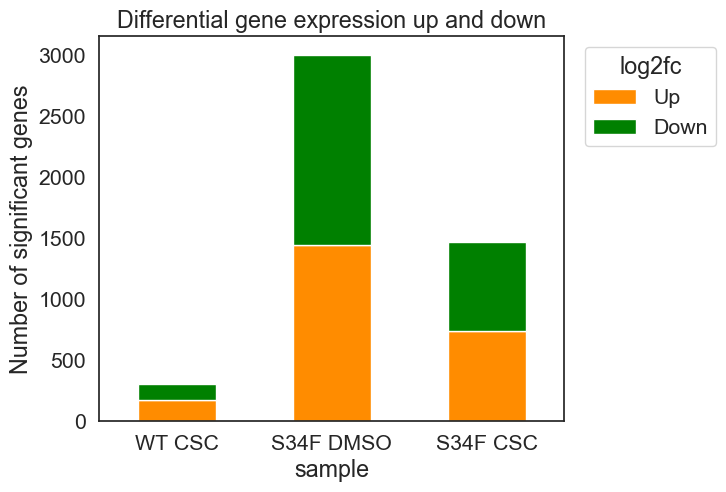

In [12]:
ax = summary_df.plot(kind='bar', stacked=True, figsize=(6,5),rot=0, color=["darkorange", "green"])
sns.set_style("white")
ax.set_ylabel("Number of significant genes")
ax.set_title("Differential gene expression up and down")
ax.legend(title="log2fc", bbox_to_anchor=(1.35, 1))
plt.savefig("/Users/selammehreteab/Downloads/updated_gene_expression_stackedbar_updwn.png", format='png', dpi=1200, bbox_inches='tight')

In [13]:
tpm_allconds = pd.read_csv('/Users/selammehreteab/Downloads/tpm_shortread.tsv', sep= '\t')
tpm_allconds 

,Unnamed: 0,Wtclone2_dmsorep1,s34fclone2_dmsorep1,s34fclone1_cscrep2,Wtclone2_cscrep2,Wtclone2_cscrep1,s34fclone1_cscrep1,Wtclone2_dmsorep2,s34fclone1_dmsorep2,s34fclone1_dmsorep1,Wtclone1_cscrep2,Wtclone1_dmsorep2,s34fclone2_cscrep2,Wtclone1_cscrep1,s34fclone2_cscrep1,Wtclone1_dmsorep1,s34fclone2_dmsorep2
0,A1BG,0.031962,0.031332,0.000000,0.017112,0.015784,0.000000,0.000000,0.000000,0.012211,0.063105,0.014658,0.014159,0.012103,0.008456,0.000000,0.013547
1,A1BG-AS1,9.005674,11.164964,13.545220,10.282180,7.862779,10.272975,11.440670,12.912627,12.436944,11.049667,9.538338,7.458483,9.212323,9.432824,12.023014,9.335297
2,A1CF,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,A2M,0.115605,0.000000,0.000000,0.041263,0.014273,0.000000,0.019318,0.000000,0.000000,0.000000,0.000000,0.000000,0.072958,0.000000,0.000000,0.097998
4,A2M-AS1,0.000000,0.049509,0.038144,0.009543,0.000000,0.004393,0.035743,0.004232,0.010215,0.000000,0.008175,0.011845,0.000000,0.007074,0.008856,0.022665
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60637,ZYX,560.549186,828.362388,573.924296,460.721531,587.246310,552.350011,608.608198,694.926842,849.184174,762.920002,673.421848,737.573328,438.928805,555.031820,544.603950,687.588351
60638,ZYXP1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
60639,ZZEF1,26.169912,10.891760,15.858641,21.264440,24.918799,18.837815,16.769322,16.342214,8.893746,13.660002,14.786250,17.730471,18.357554,16.404604,18.821837,13.946997
60640,hsa-mir-1253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [15]:
# Table with TPM for cell cycle-related genes to be used for hierarchical clustering. List of genes from Biocarta Pathways
dflist = [tpm_allconds]
set_cell_cycle = set(('CCNA1', 'CCNB1', 'CCND1', 'CCND2', 'CCND3', 'CCNE1','CCNH', 'CDC25A','CDK1', 'CDK2', 'CDK4', 'CDK6', 'CDK7', 'CDKN1A', 'CDKN1B', 'CDKN2A', 'CDKN2B', 'CDKN2C', 'CDKN2D', 'E2F1' ))
tpm_allconds = tpm_allconds[tpm_allconds['Unnamed: 0'].isin(set_cell_cycle)]
tpm_allconds = tpm_allconds.fillna(0)
tpm_allconds = tpm_allconds[['Unnamed: 0', 'Wtclone1_dmsorep1','Wtclone1_dmsorep2','Wtclone2_dmsorep1', 'Wtclone2_dmsorep2', 'Wtclone1_cscrep1', 'Wtclone1_cscrep2', 'Wtclone2_cscrep1', 'Wtclone2_cscrep2', 's34fclone1_dmsorep1', 's34fclone1_dmsorep2','s34fclone2_dmsorep1','s34fclone2_dmsorep2', 's34fclone1_cscrep1', 's34fclone1_cscrep2', 's34fclone2_cscrep1', 's34fclone2_cscrep2' ]]
tpm_allconds = tpm_allconds.set_index('Unnamed: 0')
tpm_allconds

,Wtclone1_dmsorep1,Wtclone1_dmsorep2,Wtclone2_dmsorep1,Wtclone2_dmsorep2,Wtclone1_cscrep1,Wtclone1_cscrep2,Wtclone2_cscrep1,Wtclone2_cscrep2,s34fclone1_dmsorep1,s34fclone1_dmsorep2,s34fclone2_dmsorep1,s34fclone2_dmsorep2,s34fclone1_cscrep1,s34fclone1_cscrep2,s34fclone2_cscrep1,s34fclone2_cscrep2
Unnamed: 0,,,,,,,,,,,,,,,,
CCNA1,2.394767,2.797708,2.379278,2.711039,4.367584,2.671618,2.554600,5.238320,0.662501,0.483833,0.576241,0.492757,2.781599,2.037464,1.809206,2.505657
CCNB1,37.232179,37.630788,35.552540,24.168540,29.226580,28.527748,26.148247,24.126767,40.557497,30.312704,36.250875,44.957677,52.787289,67.489361,71.927123,47.453738
CCND1,536.648865,547.654876,641.007619,551.289146,573.172993,400.925298,587.996803,803.871041,124.584991,93.304735,89.985907,111.906436,603.632073,411.303908,435.472098,403.447569
CCND2,515.659973,478.240532,498.396308,414.492114,463.668230,264.871998,336.304127,447.523632,164.243399,254.247603,134.981371,258.477028,424.090413,357.106998,356.777763,318.218087
CCND3,83.896865,101.117276,100.351721,120.097284,68.406949,98.805323,114.351896,136.715852,108.569160,93.701720,109.355381,102.875458,119.035263,122.160172,114.323110,107.404325
CCNE1,2.616751,3.269007,3.573997,3.960521,2.905135,3.205324,6.639250,5.329636,4.215619,3.092996,3.683067,3.422981,7.286637,5.476766,5.002548,6.361964
CCNH,23.771924,26.609370,25.666991,26.194837,36.589674,22.392459,27.868872,36.181931,10.787518,14.504960,8.925556,16.477569,23.124477,13.598624,19.984515,24.733015
CDC25A,16.776284,18.290870,15.850990,17.778337,18.691695,17.239829,22.640211,18.736756,7.537473,7.183642,5.765548,8.693875,30.433104,25.741915,25.512065,16.047497
CDK1,2.554654,2.212707,1.529557,1.563843,2.452575,1.552072,1.292524,2.646838,1.700611,1.431138,1.749327,5.288834,7.141130,6.518392,9.993166,6.546679


In [14]:
tpm_allconds.to_csv('/Users/selammehreteab/Downloads/cellcycle_tpm.tsv', sep = '\t')

/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_43984/116720099.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


WT DMSO vs. WT CSC: **
WT DMSO vs. MT DMSO: **
WT DMSO vs. MT CSC: ns


/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_43984/116720099.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


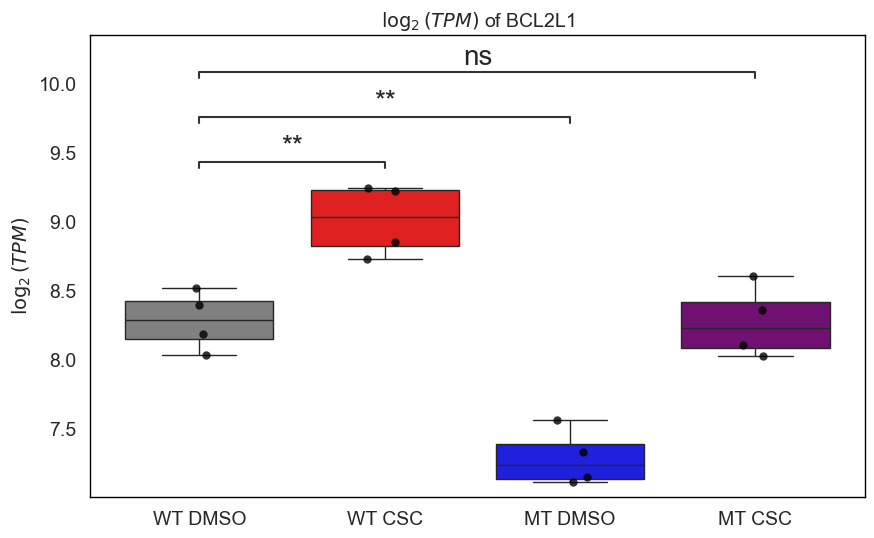

In [6]:
# Plotting the gene expression of BCL2L1 with the signficance annotated
bcl_df = tpm_allconds[tpm_allconds['Unnamed: 0'] == 'BCL2L1']
groups = {
    'WT DMSO': [c for c in tpm_allconds.columns if 'Wt' in c and 'dmso' in c],
    'WT CSC':  [c for c in tpm_allconds.columns if 'Wt' in c and 'csc' in c],
    'MT DMSO': [c for c in tpm_allconds.columns if 's34f' in c and 'dmso' in c],
    'MT CSC':  [c for c in tpm_allconds.columns if 's34f' in c and 'csc' in c]
}

plot_data = []
for group_name, cols in groups.items():
    tpm_vals = bcl_df[cols].values.flatten()
    log_vals = np.log2(tpm_vals)
    for v in log_vals:
        plot_data.append({'Condition': group_name, 'Log2TPM': v})
df_plot = pd.DataFrame(plot_data)

# significance between each comparison relative to wtdmso
def get_padj(df, gene='BCL2L1'):
    row = df[df['Unnamed: 0'] == gene]
    if row.empty:
        return np.nan
    return row['padj'].values[0]

padj_wtcsc   = get_padj(wtcsc_comparison)    
padj_mtdmso  = get_padj(s34fdmso_comparison) 
padj_mtcsc  = get_padj(s34fcsc_comparison) 

def padj_to_annotation(padj):
    if pd.isna(padj) or padj >= 0.05:
        return 'ns'
    elif padj < 0.0001:
        return '****'
    elif padj < 0.001:
        return '***'
    elif padj < 0.01:
        return '**'
    else:
        return '*'

pairs_to_test = [
    ("WT DMSO", "WT CSC"),
    ("WT DMSO", "MT DMSO"),
    ("WT DMSO", "MT CSC")
]

custom_annotations = [
    padj_to_annotation(padj_wtcsc),
    padj_to_annotation(padj_mtdmso),
    padj_to_annotation(padj_mtcsc)
]

sns.set_style("white")
plt.figure(figsize=(10, 6))

custom_palette = {
    'WT DMSO': 'gray',
    'WT CSC':  'red',
    'MT DMSO': 'blue',
    'MT CSC':  'purple'
}

ax = sns.boxplot(
    data=df_plot,
    x='Condition',
    y='Log2TPM',
    palette=custom_palette,
    showfliers=False,
)
sns.stripplot(
    data=df_plot,
    x='Condition',
    y='Log2TPM',
    color='black',
    size=6,
    alpha=0.8,
    jitter=True,
    ax=ax
)

annotator = Annotator(ax, pairs_to_test, data=df_plot, x='Condition', y='Log2TPM')
annotator.configure(
    test=None,
    text_format='simple',
    loc='inside',
    fontsize=20,
)
annotator.set_custom_annotations(custom_annotations)
annotator.annotate()

ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.grid(False)
plt.title('$\\log_2(TPM)$ of BCL2L1', fontsize=14)
plt.ylabel('$\\log_2(TPM)$', fontsize=14)
plt.xlabel('')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)
plt.savefig('/Users/selammehreteab/Downloads/upd_BCL2L1_log2TPM_boxplot.pdf', dpi=1200, bbox_inches='tight')



/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_81980/1859674497.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/var/folders/kx/0m791vkn455dvs6yj4xqbl2h0000gn/T/ipykernel_81980/1859674497.py:95: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


WT DMSO vs. WT CSC: ns
WT DMSO vs. MT DMSO: ****
WT DMSO vs. MT CSC: ns


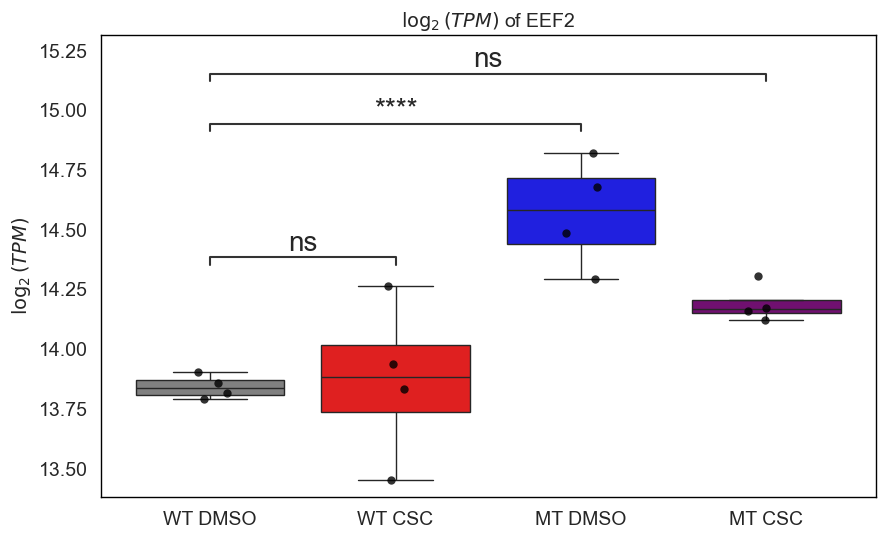

In [50]:
# Plotting the gene expression of eef2 with the signficance annotated
eef2_df = tpm_allconds[tpm_allconds['Unnamed: 0'] == 'EEF2']
groups = {
    'WT DMSO': [c for c in tpm_allconds.columns if 'Wt' in c and 'dmso' in c],
    'WT CSC':  [c for c in tpm_allconds.columns if 'Wt' in c and 'csc' in c],
    'MT DMSO': [c for c in tpm_allconds.columns if 's34f' in c and 'dmso' in c],
    'MT CSC':  [c for c in tpm_allconds.columns if 's34f' in c and 'csc' in c]
}

plot_data = []
for group_name, cols in groups.items():
    tpm_vals = eef2_df[cols].values.flatten()
    log_vals = np.log2(tpm_vals)
    for v in log_vals:
        plot_data.append({'Condition': group_name, 'Log2TPM': v})
df_plot = pd.DataFrame(plot_data)

def get_padj(df, gene='EEF2'):
    row = df[df['Unnamed: 0'] == gene]
    if row.empty:
        return np.nan
    return row['padj'].values[0]

padj_wtcsc   = get_padj(wtcsc_comparison)    
padj_mtdmso  = get_padj(s34fdmso_comparison) 
padj_mtcsc  = get_padj(s34fcsc_comparison) 

def padj_to_annotation(padj):
    if pd.isna(padj) or padj >= 0.05:
        return 'ns'
    elif padj < 0.0001:
        return '****'
    elif padj < 0.001:
        return '***'
    elif padj < 0.01:
        return '**'
    else:
        return '*'

pairs_to_test = [
    ("WT DMSO", "WT CSC"),
    ("WT DMSO", "MT DMSO"),
    ("WT DMSO", "MT CSC")
]

custom_annotations = [
    padj_to_annotation(padj_wtcsc),
    padj_to_annotation(padj_mtdmso),
    padj_to_annotation(padj_mtcsc)
]

sns.set_style("white")
plt.figure(figsize=(10, 6))

custom_palette = {
    'WT DMSO': 'gray',
    'WT CSC':  'red',
    'MT DMSO': 'blue',
    'MT CSC':  'purple'
}

ax = sns.boxplot(
    data=df_plot,
    x='Condition',
    y='Log2TPM',
    palette=custom_palette,
    showfliers=False,
)
sns.stripplot(
    data=df_plot,
    x='Condition',
    y='Log2TPM',
    color='black',
    size=6,
    alpha=0.8,
    jitter=True,
    ax=ax
)

annotator = Annotator(ax, pairs_to_test, data=df_plot, x='Condition', y='Log2TPM')
annotator.configure(
    test=None,
    text_format='simple',
    loc='inside',
    fontsize=20,
)
annotator.set_custom_annotations(custom_annotations)
annotator.annotate()

ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.grid(False)
plt.title('$\\log_2(TPM)$ of EEF2', fontsize=14)
plt.ylabel('$\\log_2(TPM)$', fontsize=14)
plt.xlabel('')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1)
plt.savefig('/Users/selammehreteab/Downloads/upd_EEF2_log2TPM_boxplot.pdf', dpi=1200, bbox_inches='tight')

In [16]:
# the genes are the set of genes that are differentially expressed in s34f dmso and differentially modified in wtcsc
tpm_allconds = pd.read_csv('/Users/selammehreteab/Downloads/tpm_shortread.tsv', sep= '\t')

set_mtexp_wcm6a = set(('ACTN4','CD59','CDKN1A','CKAP4','EEF2','HBEGF','IER3','ITGA3','JUP','LAMA3','PDIA6','PDLIM1','PRNP','SAT1', 'SNAI2', 'TGFBI', 'TNFRSF12A','ZFP36L1'))
tpm_allconds = tpm_allconds[tpm_allconds['Unnamed: 0'].isin(set_mtexp_wcm6a)]
tpm_allconds = tpm_allconds.fillna(0)
tpm_allconds = tpm_allconds[['Unnamed: 0', 'Wtclone1_dmsorep1','Wtclone1_dmsorep2','Wtclone2_dmsorep1', 'Wtclone2_dmsorep2', 'Wtclone1_cscrep1', 'Wtclone1_cscrep2', 'Wtclone2_cscrep1', 'Wtclone2_cscrep2', 's34fclone1_dmsorep1', 's34fclone1_dmsorep2','s34fclone2_dmsorep1','s34fclone2_dmsorep2', 's34fclone1_cscrep1', 's34fclone1_cscrep2', 's34fclone2_cscrep1', 's34fclone2_cscrep2' ]]
tpm_allconds = tpm_allconds.set_index('Unnamed: 0')
tpm_allconds.to_csv('/Users/selammehreteab/Downloads/morph_s34fexp_wcm6a_tpm.tsv', sep = '\t')
tpm_allconds 

,Wtclone1_dmsorep1,Wtclone1_dmsorep2,Wtclone2_dmsorep1,Wtclone2_dmsorep2,Wtclone1_cscrep1,Wtclone1_cscrep2,Wtclone2_cscrep1,Wtclone2_cscrep2,s34fclone1_dmsorep1,s34fclone1_dmsorep2,s34fclone2_dmsorep1,s34fclone2_dmsorep2,s34fclone1_cscrep1,s34fclone1_cscrep2,s34fclone2_cscrep1,s34fclone2_cscrep2
Unnamed: 0,,,,,,,,,,,,,,,,
ACTN4,900.779264,924.365161,844.192448,872.175010,602.828973,742.765321,745.396670,726.623828,1317.893338,1578.144120,1619.099636,1359.099984,795.369178,904.575009,981.324202,964.516851
CD59,413.219394,357.526597,435.311249,304.717181,317.708873,189.642533,285.520520,412.931295,120.609152,126.107874,123.237584,181.664957,298.191343,236.494589,257.958098,218.553185
CDKN1A,221.012237,222.385115,246.857518,354.972022,305.738304,379.419154,377.859477,316.471434,652.552617,784.367450,803.019860,705.307178,270.428458,347.547332,335.432550,528.326645
CKAP4,330.088333,325.834451,362.832151,301.011898,440.169431,426.086159,378.762057,368.459942,107.134036,85.993678,131.455505,125.807084,230.273785,224.688818,235.263403,280.907855
EEF2,14155.708225,14389.628859,14845.197404,15298.047938,14555.869588,19636.107153,15666.109252,11177.592670,28923.891737,22944.768354,26195.871434,20062.183841,17784.011827,20219.153066,18445.251222,18281.080223
HBEGF,121.313374,215.440543,244.182322,230.980025,252.762749,284.177681,289.428674,492.169912,9.856627,6.161794,7.211798,10.694093,233.649829,117.108134,118.432122,247.987707
IER3,27.464089,41.635465,35.804014,49.088103,34.649131,43.579261,40.858230,50.977279,8.254668,5.483705,5.755004,7.025248,33.832915,29.555341,24.044260,25.376143
ITGA3,3718.522649,4309.735584,4303.515295,5309.349097,3868.420144,5062.777523,4866.398690,4340.091050,1840.456064,1250.843168,1703.341682,1404.258902,2255.575512,2288.499194,2295.129842,3192.405002
JUP,761.752983,797.699336,603.574698,875.491711,635.729406,786.834649,658.120092,724.937293,1298.786919,1257.514752,1495.213989,1342.483651,804.418469,937.802276,961.905134,1091.721933
